# J-lens readout in the middle of generation — Qwen3.5-9B, pre-fitted lens

**Question.** The paper scores the J-lens at one prompt position: the token right before
the answer. Does the lens still retrieve the model's latent words *while the model is
writing*: at every token of its own greedy continuation? Two kinds of words are tracked:

1. the annotated **intermediates** of `data/evaluations` (e.g. *Brazil* for
   *"the ocean on the coast of the country where Carnival is most famously celebrated"*),
   at every generated position where the word is neither in the text so far nor the next
   token;
2. the model's own **future words**: content words it writes later in the same
   continuation, read *before* it writes them (planning; for poetry, the rhyme word).

**Answer (this run, §9).** Partly. The J-lens keeps retrieving latent intermediates while
the model writes, far above chance, but much less than at the prompt end, and on average
**no better than the logit lens**. Its clear advantage mid-generation is for words the model
is about to write *beyond* the next token.

* **Prompt end (the paper's protocol)** — the two lenses tie overall: AUC 0.481 vs 0.479,
  J − logit +0.002 [−0.021, +0.022]. The J-lens wins on multihop (+0.080 [+0.039, +0.127]),
  multilingual (+0.065) and association (+0.049) and loses on order-ops (−0.168), as on the
  lens's model card.
* **Mid-generation** — latent intermediates still score AUC 0.19 against 0.03–0.04 for
  controls, but hit@10 falls from 0.37 at the prompt end to 0.25 one token later and ~0.10
  from the third token on. The lenses tie again (0.191 vs 0.191, +0.001 [−0.014, +0.016]);
  the J-lens is significantly better only on association (+0.043 [+0.028, +0.061]).
* **The model's own upcoming words** — at the next token both lenses are near-perfect
  (hit@10 0.97 / 0.98), but further ahead the J-lens leads: 0.56 vs 0.49 one step beyond the
  next token, 0.23 vs 0.15 two steps, 0.17 vs 0.11 three steps (controls ≤ 0.01);
  significant on multihop, association and typo.
* Mid-generation content peaks late, at layer ~27 of 32.
* **Poetry is not informative here**: the dataset prompts end right before the rhyme word,
  so it is the next token (both lenses ≈ 1.0) and there is no generation before it.

Labels are **English only**, exactly as annotated. Chinese spellings such as `意大利` are
not accepted and count as misses; translated aliases are deliberately left for a later
run. The lens is `bcywinski/jacobian-lens-qwen3.5-9b` (`lens_n1000.pt`, fitted on 1000
WikiText-103 sequences of 128 tokens for this instruct model). Nothing is fitted here.

## Method

**Lens.** `lens_l(h) = unembed(J_l h)`, `J_l = E[∂h_final / ∂h_l]`; the logit lens is the
same readout with `J_l = I`. Both are read off the **same activations** of one forward.

**Generation.** Each prompt (right-stripped, raw text, no chat template, no BOS — Qwen has
none) is continued greedily for up to 32 tokens, stopping at the first line break after
text or at EOS (the stop token is kept). One forward over prompt + continuation then reads
both lenses at every block.

**Steps.** Step `s` is the position at which the model predicts generated token `g_s`:
step 0 is the last prompt token (the paper's readout position), step `s ≥ 1` the position
of `g_{s-1}`. At each step a tracked word is

* `in_text` — already in the prompt or in `g_0..g_{s-1}`;
* `next` — the text from `g_s` on starts with it (the model is about to write it);
* `latent` — neither. This is the paper's condition for an intermediate: *"neither
  present in the input nor identical to the predicted output"*.

**Scoring** (as in the paper's Figure 52 and `jlens.reference_plots`). A word's rank is its
1-based rank over the full vocabulary, minimised over its **whole-token** spellings
(as-is/lower/capitalised, with and without a leading space; order-ops adds digit/word and
operation synonyms). Words with no whole-token spelling are excluded, not counted as
misses. A word is *recovered at k* if its best rank over the **inner layers** 0–30 (the
model-output row excluded) is ≤ k. pass@k averages hits within an item (over words and
steps), then over items; the summary is the area under pass@k against log k for
k ∈ {1, 2, 5, 10, 20, 50, 100}, normalised so that always-rank-1 scores 1.

**Controls.** The intermediates of another item of the same dataset
(`items[(i + n//2) % n]`, as in `jlens.evaluation`), scored at the same positions under the
same `latent` rule. They are the chance level of a lens that surfaces any topical word.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
REPO_DIR = os.path.abspath("jacobian-lens-gpt2")

# Opened from a clone (notebooks/<lens>/): use the repository root above the notebook.
local_repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "jlens" / "generation_readout.py").is_file()), None)
if local_repo is not None:
    REPO_DIR = str(local_repo)
elif os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull --ff-only
else:
    !git clone {REPO_URL} {REPO_DIR}
sys.path.append(REPO_DIR)

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import transformers
from IPython.display import display
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

import jlens
from jlens.evaluation import DATASETS, load_eval, synonyms
from jlens.generated_answers import score_answer
from jlens.generation_readout import (
    LENS_ORDER,
    SWEEP_KS,
    Continuation,
    continuation_ranks,
    future_words,
    greedy_continuation,
    hit_rates,
    item_bootstrap_auc_diff,
    step_texts,
    word_pattern,
    word_status,
)
from jlens.hooks import ActivationRecorder
from jlens.readout import readout, top_token_ids
from jlens.strict_scoring import DecodedSpellings

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 240)
COLORS = {"J-lens": "tab:blue", "logit lens": "tab:purple"}

In [3]:
MODEL_ID = os.environ.get("JLENS_MODEL_ID", "Qwen/Qwen3.5-9B")
LENS_REPO, LENS_FILE = "bcywinski/jacobian-lens-qwen3.5-9b", "lens_n1000.pt"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if DEVICE == "cuda" else torch.float32
MAX_NEW_TOKENS = 32     # greedy continuation budget per prompt
STOP_AT_NEWLINE = True  # end the continuation at its first line break after text
KS = SWEEP_KS           # (1, 2, 5, 10, 20, 50, 100), as in Figure 52
K = 10                  # threshold of the per-step, per-distance and per-layer curves
SLUG = MODEL_ID.split("/")[-1].lower()
RUN_DIR = Path(os.environ.get("JLENS_RUN_DIR", Path(REPO_DIR) / "runs" / f"{SLUG}-mid-generation"))
RUN_DIR.mkdir(parents=True, exist_ok=True)
GEN_PATH, RANKS_PATH = RUN_DIR / "generations.pkl", RUN_DIR / "ranks.pkl"
torch.manual_seed(0)

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
hf_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=DTYPE).to(DEVICE)
model = jlens.from_hf(hf_model, tokenizer)
lens = jlens.JacobianLens.from_pretrained(LENS_REPO, filename=LENS_FILE)
INNER = lens.source_layers  # every block except the final one
assert lens.d_model == model.d_model and INNER == list(range(model.n_layers - 1))
VOCAB_SIZE = hf_model.config.get_text_config().vocab_size
spellings = DecodedSpellings(tokenizer, vocab_size=VOCAB_SIZE)

# Recorded with the results, per AGENTS.md's Experiment Configuration.
RUN_INFO = {
    "model_id": MODEL_ID, "dtype": str(DTYPE), "device": DEVICE,
    "gpu": torch.cuda.get_device_name() if DEVICE == "cuda" else None,
    "n_layers": model.n_layers, "d_model": model.d_model, "vocab_size": VOCAB_SIZE,
    "lens": f"{LENS_REPO}/{LENS_FILE}", "lens_n_prompts": lens.n_prompts,
    "lens_corpus": "Salesforce/wikitext wikitext-103-raw-v1, 1000 x 128 tokens",
    "prompt_format": "raw text, right-stripped, no chat template, no BOS",
    "decoding": f"greedy, max_new_tokens={MAX_NEW_TOKENS}, stop_at_newline={STOP_AT_NEWLINE}",
    "labels": "English as annotated; no translated aliases",
    "transformers": transformers.__version__, "torch": torch.__version__,
}
(RUN_DIR / "run_info.json").write_text(json.dumps(RUN_INFO, indent=1))
print(model, "|", lens)
RUN_INFO

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/427 [00:00<?, ?it/s]

HFLensModel(Qwen3_5ForCausalLM, n_layers=32, d_model=4096) | JacobianLens(d_model=4096, n_prompts=1000, source_layers=[0..30] (31 layers))


{'model_id': 'Qwen/Qwen3.5-9B',
 'dtype': 'torch.bfloat16',
 'device': 'cuda',
 'gpu': 'NVIDIA RTX A6000',
 'n_layers': 32,
 'd_model': 4096,
 'vocab_size': 248320,
 'lens': 'bcywinski/jacobian-lens-qwen3.5-9b/lens_n1000.pt',
 'lens_n_prompts': 1000,
 'lens_corpus': 'Salesforce/wikitext wikitext-103-raw-v1, 1000 x 128 tokens',
 'prompt_format': 'raw text, right-stripped, no chat template, no BOS',
 'decoding': 'greedy, max_new_tokens=32, stop_at_newline=True',
 'labels': 'English as annotated; no translated aliases',
 'transformers': '5.9.0',
 'torch': '2.12.0+cu130'}

## 1. Data

Six prompt sets from `data/evaluations` (551 items). Every item has `intermediates`;
multihop, multilingual and order-ops also have the `target` answer, used here to score
whether the generated answer is correct.

In [5]:
EVALS = {dataset: load_eval(REPO_DIR, dataset) for dataset in DATASETS}


def tracked_words(dataset: str, index: int) -> list[tuple[str, str]]:
    """(kind, word) of the annotated words of one item; controls from another item."""
    items = EVALS[dataset]
    item, other = items[index], items[(index + len(items) // 2) % len(items)]
    words = [("intermediate", word) for word in item["intermediates"]]
    words += [("control", word) for word in other["intermediates"] if word not in item["intermediates"]]
    if item.get("target"):
        words.append(("target", item["target"]))
    return words


def word_ids(word: str, dataset: str) -> list[int]:
    return sorted(spellings(word, dataset == "order-ops"))


def word_spellings(word: str, dataset: str) -> list[str]:
    return synonyms(word) if dataset == "order-ops" else [word]


coverage = pd.DataFrame([
    dict(dataset=d, kind=kind, supported=bool(word_ids(word, d)))
    for d in DATASETS for i in range(len(EVALS[d])) for kind, word in tracked_words(d, i)
]).groupby(["dataset", "kind"]).supported.agg(["sum", "count"]).unstack()
print("Whole-token coverage (supported / all):")
display(coverage)

Whole-token coverage (supported / all):


sum                       count                    
kind         control intermediate target control intermediate target
dataset                                                             
association    102.0        102.0    NaN   102.0        102.0    NaN
multihop        92.0         94.0   86.0   101.0        103.0   93.0
multilingual   418.0        426.0   79.0   420.0        428.0  107.0
order-ops       83.0        109.0   53.0    84.0        110.0   55.0
poetry          98.0         98.0    NaN    98.0         98.0    NaN
typo            96.0         96.0    NaN    96.0         96.0    NaN

## 2. Greedy continuations (cached)

Skipped when `generations.pkl` exists. One unpadded `generate` call per prompt.

In [6]:
if GEN_PATH.exists():
    generations = pd.read_pickle(GEN_PATH)
    print(f"loaded {len(generations)} continuations from {GEN_PATH}")
else:
    rows = []
    for dataset in DATASETS:
        for item in tqdm(EVALS[dataset], desc=dataset):
            prompt = item["prompt"].rstrip()
            ids = tokenizer.encode(prompt, add_special_tokens=False)
            cont = greedy_continuation(
                hf_model, tokenizer, ids,
                max_new_tokens=MAX_NEW_TOKENS, stop_at_newline=STOP_AT_NEWLINE,
            )
            rows.append(dict(
                dataset=dataset, item=item["name"], prompt=prompt, prompt_ids=ids,
                generated_ids=cont.generated_ids, stop=cont.stop,
                text=tokenizer.decode(cont.generated_ids, skip_special_tokens=True),
            ))
    generations = pd.DataFrame(rows)
    generations.to_pickle(GEN_PATH)
generations["n_steps"] = generations.generated_ids.map(len)
display(generations.groupby("dataset").agg(
    items=("item", "size"), mean_steps=("n_steps", "mean"),
    eos=("stop", lambda s: (s == "eos").mean()), newline=("stop", lambda s: (s == "newline").mean()),
).round(2))
with pd.option_context("display.max_colwidth", 90):
    display(generations.groupby("dataset").head(2)[["dataset", "prompt", "text"]])

loaded 551 continuations from /workspace/jacobian-lens-gpt2/runs/qwen3.5-9b-mid-generation/generations.pkl


,items,mean_steps,eos,newline
dataset,,,,
association,102,24.37,0.0,0.70
multihop,93,9.38,0.0,0.82
multilingual,107,7.18,0.0,0.95
order-ops,55,4.51,0.0,0.98
poetry,98,3.01,0.0,1.00
typo,96,5.77,0.0,0.95


,dataset,prompt,text
0,multihop,Fact: The ocean on the coast of the country where Carnival is most famously celebrated...,Atlantic Ocean.\n
1,multihop,Fact: The language spoken in the country where the Amazon River ends is,Portuguese.\n
93,multilingual,"Lo opuesto de ""grande"" es ""","pequeño"".\n"
94,multilingual,La saison après l'été est l',automne.\n
200,order-ops,(2 + 3) * 4 =,20.\n
201,order-ops,(7 - 3) * 2 = 8. (9 - 4) * 3 =,15. (10 - 5) * 4 = 20. (11 - 6) * 5 = 2
255,poetry,"A rhyming couplet:\nThe soldier held his final, rattling breath,\nAnd closed his eyes ...",death.\n\n
256,poetry,"A rhyming couplet:\nThe ancient tomb was sealed with heavy stone,\nInside was nothing ...",bone.\n\n
353,association,"She kept his coffee mug on the counter, washed it every morning and put it back, thoug...",\nThe 10000000000000000000000000000
354,association,"She turned down the wine with a small smile and kept one hand on the table edge, not q...",\nThe 10000000000000000000000000000


### Is the generated answer correct?

For the three sets with a `target`: the first completed phrase of the continuation is
compared with the target (`jlens.generated_answers.score_answer`; digits and number words
are equivalent). English only, no aliases.

In [7]:
TARGETS = {(d, item["name"]): item.get("target") for d in DATASETS for item in EVALS[d]}
generations["target"] = [TARGETS[(d, i)] for d, i in zip(generations.dataset, generations["item"])]
annotated = generations[generations.target.notna()].copy()
scores = pd.DataFrame([
    score_answer(r.text, r.target, dataset=r.dataset, truncated=r.stop == "max_new_tokens")
    for r in annotated.itertuples()
], index=annotated.index)
generations = generations.join(scores[["generated_answer", "answer_correct"]])
CORRECT = set(generations.loc[generations.answer_correct.eq(True), ["dataset", "item"]].itertuples(index=False, name=None))
display(generations[generations.target.notna()].groupby("dataset").answer_correct.agg(["mean", "sum", "count"]).round(3))

,mean,sum,count
dataset,,,
multihop,0.505376,47,93
multilingual,0.719626,77,107
order-ops,0.254545,14,55


## 3. Readout at every step (cached)

One forward per item over prompt + continuation; ranks of every tracked word at every
step and block, for both lenses. Tracked words: intermediates, controls, the target, the
continuation's own content words (`future`, ≥ 4 letters, not stopwords, not in the prompt,
first occurrence, with the step at which each is written) and the content words of the
control item's continuation (`future-control`). Skipped when `ranks.pkl` exists
(~10 min on an RTX A6000).

**Sanity gate.** Decoding was greedy, so the generated token must be the model's own
top-1 at the final block of the re-forward. bf16 numerics can break near-ties, so a
handful of disagreements is tolerated.

In [8]:
check = generations.sample(40, random_state=0)
agree = []
for r in check.itertuples():
    cont = Continuation(r.prompt_ids, r.generated_ids, r.stop)
    ranks = continuation_ranks(model, lens, cont, [[t] for t in cont.generated_ids])
    agree += [ranks[1, s, -1, s] == 1 for s in range(cont.n_steps)]
print(f"generated token is the final-block top-1 at {np.mean(agree):.1%} of {len(agree)} steps")
assert np.mean(agree) > 0.97

generated token is the final-block top-1 at 99.1% of 424 steps


In [9]:
INDEX = {(d, item["name"]): i for d in DATASETS for i, item in enumerate(EVALS[d])}
BY_KEY = generations.set_index(["dataset", "item"])


def item_rows(row) -> list[dict]:
    cont = Continuation(row.prompt_ids, row.generated_ids, row.stop)
    index = INDEX[(row.dataset, row.item)]
    items = EVALS[row.dataset]
    other = items[(index + len(items) // 2) % len(items)]["name"]
    other_row = BY_KEY.loc[(row.dataset, other)]
    other_cont = Continuation(other_row.prompt_ids, other_row.generated_ids, other_row.stop)
    words = [(kind, word, None) for kind, word in tracked_words(row.dataset, index)]
    words += [("future", word, step) for word, step in future_words(tokenizer, cont)]
    words += [("future-control", word, None) for word, _ in future_words(tokenizer, other_cont)]
    ids = [word_ids(word, row.dataset) for _, word, _ in words]
    ranks = continuation_ranks(model, lens, cont, ids)
    contexts, rests = step_texts(tokenizer, cont)
    out = []
    for w, (kind, word, emit) in enumerate(words):
        if not ids[w]:
            continue  # no whole-token spelling: unsupported, excluded
        pattern = word_pattern(word_spellings(word, row.dataset) if kind != "future" else [word])
        for s in range(cont.n_steps):
            status = word_status(contexts[s], rests[s], pattern)
            for li, lens_name in enumerate(LENS_ORDER):
                out.append(dict(
                    dataset=row.dataset, item=row.item, kind=kind, word=word, step=s,
                    status=status, distance=np.nan if emit is None else emit - s,
                    lens=lens_name, ranks=ranks[li, s, :, w],
                ))
    return out


if RANKS_PATH.exists():
    ranks_df = pd.read_pickle(RANKS_PATH)
    print(f"loaded {len(ranks_df)} rows from {RANKS_PATH}")
else:
    rows = []
    for row in tqdm(list(generations.itertuples()), desc="readout"):
        rows += item_rows(row)
    ranks_df = pd.DataFrame(rows)
    ranks_df.to_pickle(RANKS_PATH)
RANKS = np.stack(ranks_df["ranks"].to_numpy())  # [rows, n_layers]
ranks_df["best_rank"] = RANKS[:, INNER].min(axis=1)
ranks_df["correct"] = [(d, i) in CORRECT for d, i in zip(ranks_df.dataset, ranks_df["item"])]
display(ranks_df[ranks_df.lens.eq("J-lens")].groupby(["kind", "status"]).size().unstack(fill_value=0))

loaded 96680 rows from /workspace/jacobian-lens-gpt2/runs/qwen3.5-9b-mid-generation/ranks.pkl


status,in_text,latent,next
kind,,,
control,145,7396,3
future,9059,8370,847
future-control,257,12859,12
intermediate,629,7049,117
target,559,880,158


## 4. One example, step by step

A multihop item the model answers correctly, read at every step. Left: the token at the
read position and the next token the model writes; then each lens's top-1 at a few
layers. Right: the rank of the intermediate at every (step, layer).

In [10]:
@torch.inference_mode()
def top1_grid(cont: Continuation, layers: list[int], use_jacobian: bool) -> pd.DataFrame:
    input_ids = torch.tensor([cont.token_ids], device=model.input_device)
    with ActivationRecorder(model.layers, at=layers) as recorder:
        model.forward(input_ids)
    rows = slice(cont.start, cont.start + cont.n_steps)
    grid = {}
    for layer in layers:
        hidden = recorder.activations[layer][0, rows].float()
        if use_jacobian and layer in lens.jacobians:
            hidden = lens.transport(hidden, layer)
        top = top_token_ids(readout(model, hidden).ranking_scores, 1)[:, 0].tolist()
        grid[f"L{layer}"] = [tokenizer.decode([t]) for t in top]
    frame = pd.DataFrame(grid)
    frame.insert(0, "writes next", [tokenizer.decode([t]) for t in cont.generated_ids])
    frame.insert(0, "read at", [tokenizer.decode([t]) for t in cont.token_ids[rows]])
    return frame


latent_mid = ranks_df[ranks_df.kind.eq("intermediate") & ranks_df.status.eq("latent") & ranks_df.step.ge(1)]
candidates = generations[
    generations.dataset.eq("multihop") & generations.answer_correct.eq(True) & generations.n_steps.ge(3)
    & generations["item"].isin(latent_mid["item"])
]
example = candidates.iloc[0] if len(candidates) else generations[generations.dataset.eq("multihop")].iloc[0]
cont = Continuation(example.prompt_ids, example.generated_ids, example.stop)
word = EVALS["multihop"][INDEX[("multihop", example["item"])]]["intermediates"][0]
print(f"prompt: {example.prompt!r}\ncontinuation: {example.text!r}\nintermediate: {word!r}")
SHOW = [8, 12, 16, 20, 24, 28, model.n_layers - 1]
for use_jacobian, name in [(True, "J-lens"), (False, "logit lens")]:
    print(f"--- {name} top-1")
    display(top1_grid(cont, SHOW, use_jacobian))

prompt: 'Fact: The language spoken in the country where the Amazon River ends is'
continuation: ' Portuguese.\n'
intermediate: 'Brazil'
--- J-lens top-1


,read at,writes next,L8,L12,L16,L20,L24,L28,L31
0,is,Portuguese,。\,。\,____,languages,西班牙语,Portuguese,Portuguese
1,Portuguese,.,葡萄牙,葡萄牙,Portuguese,".\""",Portuguese,.,.
2,.,\n,<|endoftext|>,。\,.\,\n,Question,Fact,\n


--- logit lens top-1


,read at,writes next,L8,L12,L16,L20,L24,L28,L31
0,is,Portuguese,...,...,...,languages,英语,Portuguese,Portuguese
1,Portuguese,.,/,/,‑,uese,-language,.,.
2,.,\n,,,\n,事实,事实,Fact,\n


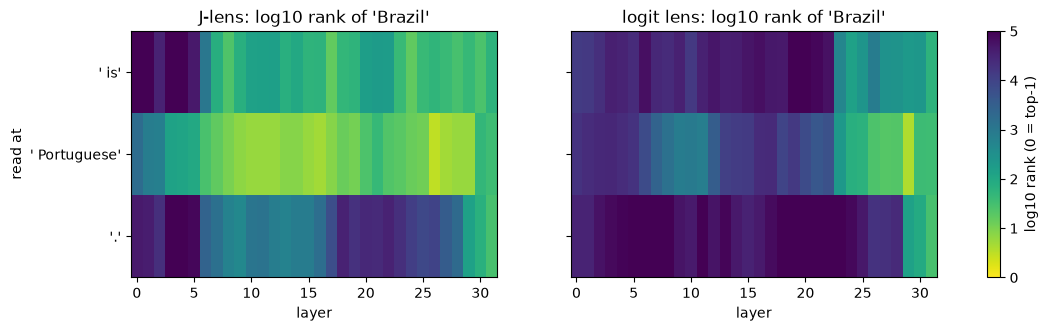

In [11]:
rows = ranks_df[ranks_df["item"].eq(example["item"]) & ranks_df.dataset.eq("multihop")
                & ranks_df.kind.eq("intermediate") & ranks_df.word.eq(word)]
labels = [repr(tokenizer.decode([t])) for t in cont.token_ids[cont.start:cont.start + cont.n_steps]]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.2), sharey=True)
for ax, lens_name in zip(axes, LENS_ORDER):
    grid = np.log10(np.stack(rows[rows.lens.eq(lens_name)].sort_values("step").ranks))
    image = ax.imshow(grid, aspect="auto", cmap="viridis_r", vmin=0, vmax=5)
    ax.set_title(f"{lens_name}: log10 rank of {word!r}")
    ax.set_xlabel("layer")
    ax.set_yticks(range(len(labels)), labels)
axes[0].set_ylabel("read at")
fig.colorbar(image, ax=axes, label="log10 rank (0 = top-1)")
plt.show()

## 5. Intermediates at the prompt end vs in the middle of generation

The Figure 52 measurement at two kinds of positions:

* **prompt end** — step 0, the paper's protocol (all intermediates, whatever their status);
* **mid-generation** — every step ≥ 1 at which the intermediate is `latent`.

Solid bars: intermediates; hatched: controls at the same positions. The margin between
them, not the raw height, is what a lens adds over chance.

,dataset,readout,kind,lens,pass@1,pass@2,pass@5,pass@10,pass@20,pass@50,pass@100,auc,n_items,n_rows
0,multihop,prompt end,intermediate,J-lens,0.155,0.214,0.315,0.488,0.583,0.702,0.780,0.461,84,94
1,multihop,prompt end,intermediate,logit lens,0.095,0.155,0.232,0.337,0.486,0.641,0.782,0.381,84,94
2,multihop,prompt end,control,J-lens,0.012,0.012,0.012,0.012,0.048,0.114,0.169,0.048,83,92
3,multihop,prompt end,control,logit lens,0.012,0.012,0.060,0.060,0.096,0.137,0.185,0.077,83,92
4,multilingual,prompt end,intermediate,J-lens,0.279,0.323,0.420,0.460,0.505,0.547,0.591,0.448,107,426
5,multilingual,prompt end,intermediate,logit lens,0.164,0.232,0.323,0.382,0.442,0.538,0.597,0.383,107,426
6,multilingual,prompt end,control,J-lens,0.000,0.000,0.000,0.013,0.016,0.031,0.054,0.014,107,418
7,multilingual,prompt end,control,logit lens,0.000,0.000,0.000,0.002,0.005,0.008,0.023,0.004,107,418
8,order-ops,prompt end,intermediate,J-lens,0.018,0.036,0.155,0.236,0.391,0.645,0.782,0.310,55,109
9,order-ops,prompt end,intermediate,logit lens,0.036,0.200,0.291,0.445,0.627,0.827,0.909,0.478,55,109


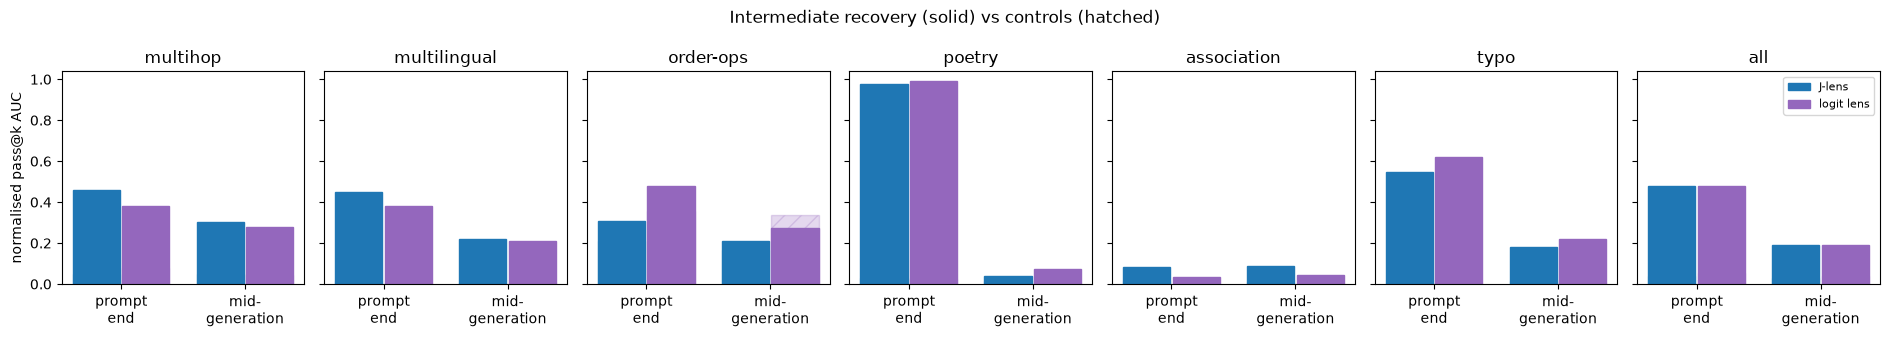

In [12]:
probe = ranks_df[ranks_df.kind.isin(["intermediate", "control"])]
readouts = pd.concat([
    probe[probe.step.eq(0)].assign(readout="prompt end"),
    probe[probe.step.ge(1) & probe.status.eq("latent")].assign(readout="mid-generation"),
])
fig52 = hit_rates(readouts, ["dataset", "readout", "kind", "lens"], ks=KS)
pooled = hit_rates(readouts, ["readout", "kind", "lens"], ks=KS).assign(dataset="all")
fig52 = pd.concat([fig52, pooled], ignore_index=True)
display(fig52.round(3))

READOUTS = ["prompt end", "mid-generation"]
fig, axes = plt.subplots(1, 7, figsize=(19, 3.4), sharey=True)
for ax, dataset in zip(axes, [*DATASETS, "all"]):
    for r, readout_name in enumerate(READOUTS):
        for l, lens_name in enumerate(LENS_ORDER):
            for kind, hatch in [("intermediate", None), ("control", "//")]:
                value = fig52.query("dataset == @dataset and readout == @readout_name and kind == @kind and lens == @lens_name").auc
                x = r + (l - 0.5) * 0.4
                if len(value):
                    ax.bar(x, value.iloc[0], 0.38, color=COLORS[lens_name],
                           alpha=1 if hatch is None else 0.25, hatch=hatch, edgecolor=COLORS[lens_name])
    ax.set_xticks(range(len(READOUTS)), ["prompt\nend", "mid-\ngeneration"])
    ax.set_title(dataset)
axes[0].set_ylabel("normalised pass@k AUC")
axes[-1].legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in COLORS.values()], labels=list(COLORS), fontsize=8)
fig.suptitle("Intermediate recovery (solid) vs controls (hatched)")
plt.tight_layout()
plt.show()

In [13]:
ci_rows = []
for dataset in [*DATASETS, "all"]:
    for readout_name in READOUTS:
        for kind in ["intermediate", "control"]:
            frame = readouts.query("readout == @readout_name and kind == @kind")
            if dataset != "all":
                frame = frame[frame.dataset.eq(dataset)]
            if frame.empty:
                continue
            diff, lo, hi = item_bootstrap_auc_diff(frame.assign(item=frame.dataset + "/" + frame["item"]), ks=KS)
            ci_rows.append(dict(dataset=dataset, readout=readout_name, kind=kind,
                                auc_J_minus_logit=diff, ci_low=lo, ci_high=hi,
                                n_items=frame["item"].nunique()))
auc_ci = pd.DataFrame(ci_rows)
print("J-lens minus logit lens AUC, paired item bootstrap 95% CI:")
display(auc_ci.round(3))

J-lens minus logit lens AUC, paired item bootstrap 95% CI:


,dataset,readout,kind,auc_J_minus_logit,ci_low,ci_high,n_items
0,multihop,prompt end,intermediate,0.080,0.039,0.127,84
1,multihop,prompt end,control,-0.029,-0.063,0.002,83
2,multihop,mid-generation,intermediate,0.025,-0.007,0.056,81
3,multihop,mid-generation,control,0.005,-0.020,0.026,83
4,multilingual,prompt end,intermediate,0.065,0.045,0.090,107
5,multilingual,prompt end,control,0.010,0.003,0.019,107
6,multilingual,mid-generation,intermediate,0.011,-0.007,0.030,107
7,multilingual,mid-generation,control,-0.008,-0.013,-0.002,107
8,order-ops,prompt end,intermediate,-0.168,-0.222,-0.109,55
9,order-ops,prompt end,control,-0.145,-0.223,-0.067,50


### 5b. Only items whose generated answer is correct

The lens can only show a step the model actually computes. Multihop, multilingual and
order-ops, restricted to items whose first generated phrase is the target.

In [14]:
correct_only = readouts[readouts.correct & readouts.kind.eq("intermediate")]
display(hit_rates(correct_only, ["dataset", "readout", "lens"], ks=KS)[
    ["dataset", "readout", "lens", "pass@1", "pass@10", "pass@100", "auc", "n_items", "n_rows"]
].round(3))

,dataset,readout,lens,pass@1,pass@10,pass@100,auc,n_items,n_rows
0,multihop,prompt end,J-lens,0.191,0.532,0.872,0.523,47,50
1,multihop,prompt end,logit lens,0.128,0.362,0.862,0.428,47,50
2,multilingual,prompt end,J-lens,0.289,0.472,0.592,0.456,77,307
3,multilingual,prompt end,logit lens,0.172,0.383,0.603,0.387,77,307
4,order-ops,prompt end,J-lens,0.036,0.250,0.893,0.338,14,28
5,order-ops,prompt end,logit lens,0.036,0.429,1.000,0.511,14,28
6,multihop,mid-generation,J-lens,0.176,0.389,0.751,0.403,46,211
7,multihop,mid-generation,logit lens,0.136,0.355,0.757,0.385,46,211
8,multilingual,mid-generation,J-lens,0.085,0.209,0.442,0.227,77,1243
9,multilingual,mid-generation,logit lens,0.057,0.208,0.445,0.222,77,1243


## 6. Do intermediates persist while the model writes?

hit@10 of latent intermediates (solid) and controls (dashed) at each generation step,
pooled over datasets (items weighted equally within a step). The item count shrinks with
the step because continuations end.

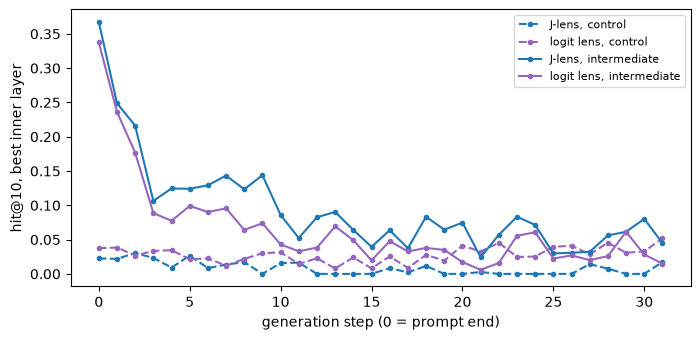

,"control, J-lens","control, logit lens","intermediate, J-lens","intermediate, logit lens",n_items
step,,,,,
0,0.023,0.037,0.367,0.337,445
1,0.022,0.038,0.249,0.236,443
2,0.031,0.027,0.216,0.177,371
3,0.023,0.033,0.106,0.089,297
4,0.009,0.035,0.125,0.077,212
5,0.027,0.021,0.124,0.099,180
6,0.008,0.023,0.129,0.090,169
7,0.014,0.012,0.143,0.096,157
8,0.017,0.022,0.123,0.064,148


In [15]:
latent = probe[probe.status.eq("latent")]
by_step = hit_rates(latent, ["step", "kind", "lens"], ks=(1, K))
max_step = int(by_step[by_step.n_items >= 20].step.max())
fig, ax = plt.subplots(figsize=(8, 3.6))
for (kind, lens_name), group in by_step[by_step.step.le(max_step)].groupby(["kind", "lens"]):
    ax.plot(group.step, group[f"pass@{K}"], color=COLORS[lens_name],
            linestyle="-" if kind == "intermediate" else "--", marker="o", ms=3, label=f"{lens_name}, {kind}")
ax.set_xlabel("generation step (0 = prompt end)")
ax.set_ylabel(f"hit@{K}, best inner layer")
ax.legend(fontsize=8)
plt.show()
step_table = by_step[by_step.step.le(max_step)].pivot_table(index="step", columns=["kind", "lens"], values=f"pass@{K}")
step_table.columns = [f"{kind}, {lens_name}" for kind, lens_name in step_table.columns]
step_table["n_items"] = by_step[by_step.kind.eq("intermediate") & by_step.lens.eq("J-lens")].set_index("step").n_items
display(step_table.round(3))

## 7. The model's own future words

Every content word the model writes later in its continuation is read at the steps
*before* it is written. `distance` = steps until the word is written: 0 means it is the next
token (a next-token readout, where the logit lens is strong by construction); ≥ 1 means
the word is still ahead of the next token. Controls: content words of another item's
continuation, read at the same positions.

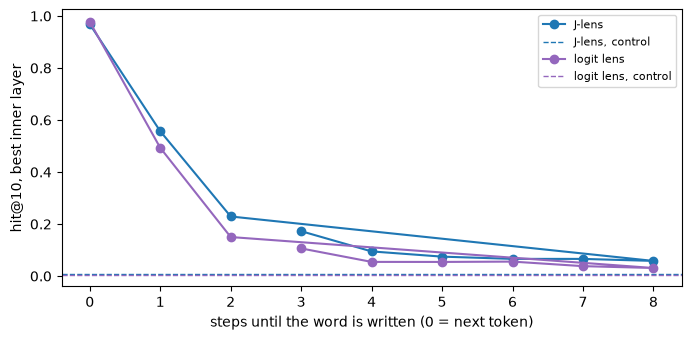

,J-lens,logit lens,n_items
distance,,,
0.0,0.969,0.977,319
1.0,0.557,0.493,165
2.0,0.229,0.150,155
3.0,0.173,0.106,142
4.0,0.095,0.054,136
5.0,0.075,0.054,128
6.0,0.066,0.056,123
7.0,0.066,0.038,116
8.0,0.058,0.031,113


In [16]:
future = ranks_df[ranks_df.kind.eq("future") & ranks_df.distance.ge(0)]
future_control = ranks_df[ranks_df.kind.eq("future-control") & ranks_df.status.eq("latent")]
by_distance = hit_rates(future, ["distance", "lens"], ks=(1, K))
chance = hit_rates(future_control, ["lens"], ks=(1, K)).set_index("lens")[f"pass@{K}"]
shown = by_distance[by_distance.distance.le(8) & by_distance.n_items.ge(20)]
fig, ax = plt.subplots(figsize=(8, 3.6))
for lens_name, group in shown.groupby("lens"):
    ax.plot(group.distance, group[f"pass@{K}"], marker="o", color=COLORS[lens_name], label=lens_name)
    ax.axhline(chance[lens_name], color=COLORS[lens_name], linestyle="--", lw=1, label=f"{lens_name}, control")
ax.set_xlabel("steps until the word is written (0 = next token)")
ax.set_ylabel(f"hit@{K}, best inner layer")
ax.legend(fontsize=8)
plt.show()
display(shown.pivot_table(index="distance", columns="lens", values=f"pass@{K}").round(3)
        .join(shown[shown.lens.eq("J-lens")].set_index("distance").n_items))

In [17]:
ahead = future[future.distance.ge(1)].assign(readout="future word, >= 1 step ahead")
ahead_table = hit_rates(ahead, ["dataset", "lens"], ks=KS)
ahead_ci = [
    dict(dataset=d, **dict(zip(["auc_J_minus_logit", "ci_low", "ci_high"],
                               item_bootstrap_auc_diff(ahead[ahead.dataset.eq(d)], ks=KS))))
    for d in DATASETS if ahead.dataset.eq(d).any()
]
print("Future words at least one step beyond the next token:")
display(ahead_table.round(3))
display(pd.DataFrame(ahead_ci).round(3))

Future words at least one step beyond the next token:


,dataset,lens,pass@1,pass@2,pass@5,pass@10,pass@20,pass@50,pass@100,auc,n_items,n_rows
0,multihop,J-lens,0.074,0.090,0.122,0.156,0.208,0.317,0.372,0.186,25,1063
1,multihop,logit lens,0.069,0.083,0.100,0.126,0.167,0.226,0.324,0.149,25,1063
2,multilingual,J-lens,0.002,0.025,0.057,0.064,0.116,0.258,0.340,0.115,16,491
3,multilingual,logit lens,0.020,0.031,0.134,0.163,0.203,0.236,0.313,0.155,16,491
4,order-ops,J-lens,0.121,0.152,0.152,0.182,0.333,0.364,0.485,0.248,1,33
5,order-ops,logit lens,0.121,0.152,0.152,0.242,0.303,0.394,0.576,0.264,1,33
6,association,J-lens,0.032,0.053,0.096,0.131,0.175,0.255,0.328,0.148,85,6092
7,association,logit lens,0.021,0.030,0.054,0.087,0.115,0.168,0.227,0.096,85,6092
8,typo,J-lens,0.195,0.234,0.354,0.396,0.441,0.580,0.652,0.404,38,630
9,typo,logit lens,0.161,0.202,0.260,0.314,0.336,0.453,0.536,0.318,38,630


,dataset,auc_J_minus_logit,ci_low,ci_high
0,multihop,0.036,0.022,0.054
1,multilingual,-0.040,-0.103,0.007
2,order-ops,-0.016,-0.016,-0.016
3,association,0.052,0.038,0.066
4,typo,0.086,0.026,0.142


### 7b. Poetry: the rhyme word before it is written

The poetry prompts stop inside the second line; the last content word the model writes in
that line is its rhyme. The paper finds the planned rhyme at the newline *before* the
second line; here it is read at every position of the line the model writes.

In [18]:
poetry_future = future[future.dataset.eq("poetry")]
last_word = poetry_future.groupby("item").word.last()
rhyme = poetry_future[[w == last_word.get(i) for i, w in zip(poetry_future["item"], poetry_future.word)]]
rhyme_by_distance = hit_rates(rhyme, ["distance", "lens"], ks=(1, K))
display(rhyme_by_distance[rhyme_by_distance.n_items.ge(10)].pivot_table(
    index="distance", columns="lens", values=["pass@1", f"pass@{K}"]).round(3))

pass@1            pass@10           
lens     J-lens logit lens  J-lens logit lens
distance                                     
0.0       0.859      0.887   0.986        1.0

## 8. Which layers carry them?

hit@10 at each single layer: latent intermediates mid-generation, their controls, and
future words at least one step ahead. The band where the J-lens curve exceeds the
logit lens's is where transport matters.

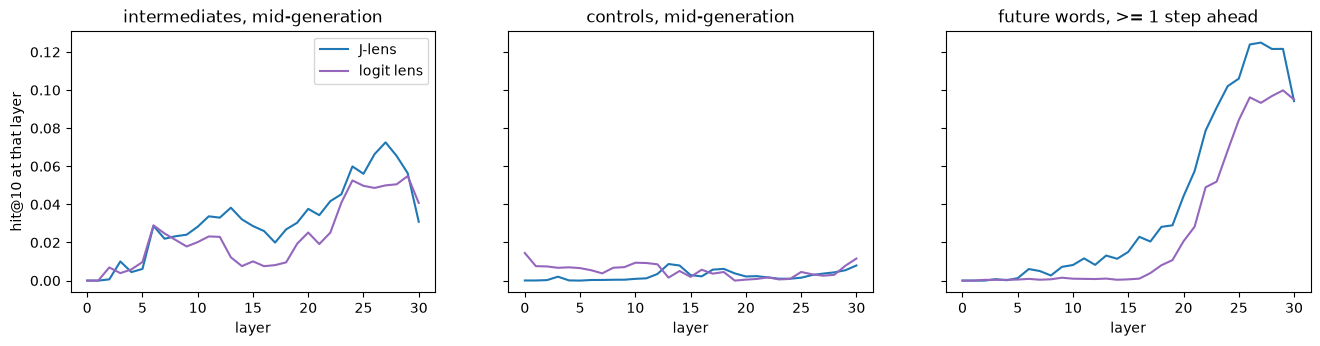

{'intermediates, mid-generation': 27,
 'controls, mid-generation': 13,
 'future words, >= 1 step ahead': 27}

In [19]:
def layer_curve(frame: pd.DataFrame) -> pd.DataFrame:
    ranks = np.stack(frame["ranks"].to_numpy())
    hits = pd.DataFrame(ranks[:, INNER] <= K, columns=INNER, index=frame.index)
    hits[["lens", "item"]] = frame[["lens", "item"]].assign(item=frame.dataset + "/" + frame["item"])
    return hits.groupby(["lens", "item"]).mean().groupby("lens").mean().T


series = {
    "intermediates, mid-generation": readouts.query("readout == 'mid-generation' and kind == 'intermediate'"),
    "controls, mid-generation": readouts.query("readout == 'mid-generation' and kind == 'control'"),
    "future words, >= 1 step ahead": ahead,
}
curves = {name: layer_curve(frame) for name, frame in series.items()}
fig, axes = plt.subplots(1, 3, figsize=(16, 3.4), sharey=True)
for ax, (name, curve) in zip(axes, curves.items()):
    for lens_name in LENS_ORDER:
        ax.plot(curve.index, curve[lens_name], color=COLORS[lens_name], label=lens_name)
    ax.set_title(name)
    ax.set_xlabel("layer")
axes[0].set_ylabel(f"hit@{K} at that layer")
axes[0].legend()
plt.show()
peak = {name: int(curve["J-lens"].idxmax()) for name, curve in curves.items()}
peak

## 9. Conclusions

In [20]:
def auc(dataset, readout_name, kind, lens_name):
    return fig52.query("dataset == @dataset and readout == @readout_name and kind == @kind and lens == @lens_name").auc.iloc[0]


for readout_name in READOUTS:
    j, l = auc("all", readout_name, "intermediate", "J-lens"), auc("all", readout_name, "intermediate", "logit lens")
    jc, lc = auc("all", readout_name, "control", "J-lens"), auc("all", readout_name, "control", "logit lens")
    row = auc_ci.query("dataset == 'all' and readout == @readout_name and kind == 'intermediate'").iloc[0]
    print(f"{readout_name:15s} intermediates AUC: J {j:.3f} vs logit {l:.3f} "
          f"(diff {row.auc_J_minus_logit:+.3f} [{row.ci_low:+.3f}, {row.ci_high:+.3f}]); "
          f"controls J {jc:.3f}, logit {lc:.3f}; margin J {j - jc:+.3f}, logit {l - lc:+.3f}")
significant = auc_ci[(auc_ci.kind == "intermediate") & ((auc_ci.ci_low > 0) | (auc_ci.ci_high < 0))]
print("\nDatasets with a significant J - logit AUC difference on intermediates:")
for r in significant.itertuples():
    print(f"  {r.dataset:12s} {r.readout:15s} {r.auc_J_minus_logit:+.3f} [{r.ci_low:+.3f}, {r.ci_high:+.3f}]")
d = by_distance.set_index(["distance", "lens"])[f"pass@{K}"]
print(f"\nFuture words, hit@{K}: next token J {d[(0, 'J-lens')]:.3f} / logit {d[(0, 'logit lens')]:.3f}; "
      f"1 step ahead J {d[(1, 'J-lens')]:.3f} / logit {d[(1, 'logit lens')]:.3f}; "
      f"2 steps ahead J {d[(2, 'J-lens')]:.3f} / logit {d[(2, 'logit lens')]:.3f}; "
      f"controls J {chance['J-lens']:.3f} / logit {chance['logit lens']:.3f}")
print(f"Peak J-lens layers: {peak}")

prompt end      intermediates AUC: J 0.481 vs logit 0.479 (diff +0.002 [-0.021, +0.022]); controls J 0.039, logit 0.052; margin J +0.442, logit +0.427
mid-generation  intermediates AUC: J 0.191 vs logit 0.191 (diff +0.001 [-0.014, +0.016]); controls J 0.030, logit 0.041; margin J +0.161, logit +0.149

Datasets with a significant J - logit AUC difference on intermediates:
  multihop     prompt end      +0.080 [+0.039, +0.127]
  multilingual prompt end      +0.065 [+0.045, +0.090]
  order-ops    prompt end      -0.168 [-0.222, -0.109]
  order-ops    mid-generation  -0.065 [-0.119, -0.017]
  poetry       prompt end      -0.010 [-0.021, -0.001]
  association  prompt end      +0.049 [+0.018, +0.081]
  association  mid-generation  +0.043 [+0.028, +0.061]

Future words, hit@10: next token J 0.969 / logit 0.977; 1 step ahead J 0.557 / logit 0.493; 2 steps ahead J 0.229 / logit 0.150; controls J 0.008 / logit 0.005
Peak J-lens layers: {'intermediates, mid-generation': 27, 'controls, mid-generat

**Interpretation.**

* **Readable, but fading.** A hidden step stays in the J-space after the model starts
  answering — in §4, *Brazil* is in the J-lens top 10 from layer 6 to 29 at the position of
  the just-written *Portuguese*, where the logit lens finds it only after layer 23. Averaged
  over items, though, the signal drops quickly after the first generated token. Much of this
  is expected of the model rather than the lens: most generated positions here are the
  answer word and the punctuation after it, when the intermediate is no longer needed.
* **J vs logit is task-dependent, as at the prompt end.** Pooled over datasets the two tie at
  both kinds of position. On order-ops the logit lens's higher score is not specific: its
  mid-generation controls (numbers from another item) score *higher* than the true
  intermediates (AUC 0.336 vs 0.274), while the J-lens keeps a positive margin
  (0.209 vs 0.167).
* **Planning is where the J-lens helps most during generation.** Words the model writes two
  or three tokens later are found ~1.5× as often by the J-lens as by the logit lens, peaking
  at layers 25–29; at the next token, where the logit lens is a next-token readout by
  construction, the two are equal.

**Limitations.**

* Continuations are short (stop at the first line break): 3–9 tokens except association,
  where two continuations degenerate into digit strings. Mid-generation counts per item vary.
* Labels are English only. Qwen often reads concepts in Chinese (`葡萄牙`, `意大利` in §4 and
  the smoke test), which count as misses here; translated aliases are deferred.
* One greedy continuation per prompt, one lens, bf16; the controls are the dataset's
  convention (another item's words), not a matched-frequency baseline.

**Next.** Cut the poetry prompts at the newline after line 1 (the paper's readout point) so
the model writes the whole second line and the rhyme word lies several tokens ahead; then
add Chinese aliases for the labels.